# Klasyfikacja obrazów CIFAR-10 za pomocą w pełni połączonej sieci neuronowej (MLP)
**Autor:** [119111]

## 1. Wstęp i opis architektury
Celem zadania jest zaimplementowanie sieci neuronowej typu Multi-Layer Perceptron (MLP) do klasyfikacji obrazów z popularnego zbioru CIFAR-10, który zawiera 60 000 obrazków w 10 klasach (wymiary 32x32 piksele, 3 kanały RGB).

**Architektura Sieci:**
Ponieważ jest to sieć w pełni połączona (Dense/Linear), pierwszym krokiem jest operacja **Flatten**, która "spłaszcza" trójwymiarowy obraz (3x32x32) do jednowymiarowego wektora o długości 3072 pikseli. 
Następnie dane przechodzą przez warstwy ukryte (zastosowano parametryczną strukturę, co pozwoli na eksperymentowanie z liczbą neuronów). Każdą warstwę liniową ($Z = WX + b$) przepuszczamy przez nieliniową funkcję aktywacji **ReLU**, aby sieć mogła uczyć się skomplikowanych zależności. Na koniec dodano mechanizm **Dropout**, który "wyłącza" losowe neurony podczas treningu, zapobiegając przeuczeniu (overfitting). Ostatnia warstwa mapuje wyniki na 10 klas wyjściowych.

**Wybór hiperparametrów startowych:**
- **Funkcja straty:** `CrossEntropyLoss` – standard dla problemów wieloklasowej klasyfikacji (łączy w sobie Softmax i Negative Log Likelihood).
- **Optymalizator:** `Adam` – adaptacyjny algorytm gradientowy, zazwyczaj zbiega szybciej niż standardowe SGD.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Sprawdzenie dostępności GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Trening będzie odbywał się na: {device}')

Trening będzie odbywał się na: cuda


## 2. Analiza zbioru danych CIFAR-10
Zanim zbudujemy model, musimy przyjrzeć się danym. Sprawdzimy wymiary, zakresy wartości pikseli oraz wyświetlimy kilka przykładowych obrazów, aby zrozumieć, z jak trudnym problemem mierzy się nasza sieć.

100.0%



Liczba próbek treningowych: 50000
Liczba próbek testowych: 10000
Wymiary pojedynczego obrazu (Kanały, Wysokość, Szerokość): torch.Size([3, 32, 32])
Zakres wartości po normalizacji: min=-1.00, max=1.00


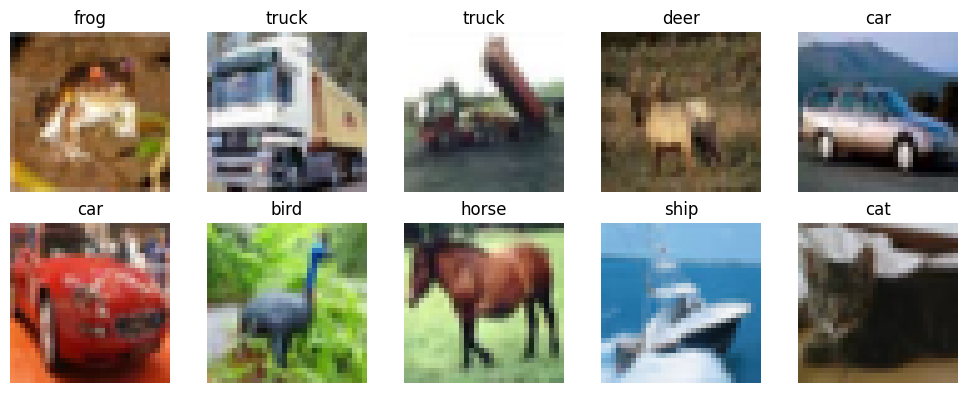

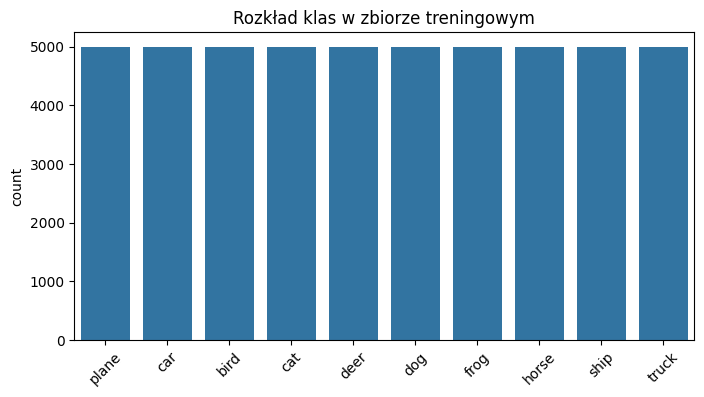

In [2]:
# Przygotowanie transformacji (zamiana na Tensor i normalizacja)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Średnia i odchylenie std dla 3 kanałów
])

# Pobieranie danych
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(f"\nLiczba próbek treningowych: {len(trainset)}")
print(f"Liczba próbek testowych: {len(testset)}")

# Sprawdzenie pojedynczej próbki
sample_image, sample_label = trainset[0]
print(f"Wymiary pojedynczego obrazu (Kanały, Wysokość, Szerokość): {sample_image.shape}")
print(f"Zakres wartości po normalizacji: min={sample_image.min().item():.2f}, max={sample_image.max().item():.2f}")

# Wizualizacja przykładowych obrazów
def imshow(img):
    img = img / 2 + 0.5     # de-normalizacja
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

fig = plt.figure(figsize=(10, 4))
for i in range(10):
    ax = fig.add_subplot(2, 5, i+1)
    img, label = trainset[i]
    imshow(img)
    ax.set_title(classes[label])
plt.tight_layout()
plt.show()

# Rozkład klas (sprawdzenie czy zbiór jest zbalansowany)
labels = [label for _, label in trainset]
plt.figure(figsize=(8,4))
sns.countplot(x=labels)
plt.title('Rozkład klas w zbiorze treningowym')
plt.xticks(ticks=np.arange(10), labels=classes, rotation=45)
plt.show()

**Wnioski z analizy:** Zbiór jest idealnie zbalansowany (po 5000 obrazków na klasę w zbiorze treningowym). Obrazki są bardzo małe (32x32), co dla człowieka bywa trudne do rozpoznania, a modelowi MLP (bez konwolucji) będzie przysparzać trudności w rozpoznawaniu przestrzennych cech obiektu. Wartości pikseli po normalizacji mieszczą się w zakresie [-1, 1], co stabilizuje proces uczenia.

## 3. Definicja modelu i funkcji pomocniczych
Tworzymy elastyczną klasę sieci, która pozwoli nam w pętlach zmieniać liczbę neuronów i wartość dropoutu bez konieczności przepisywania kodu. Definiujemy również uniwersalną pętlę treningową.

In [3]:
class CIFAR10_MLP(nn.Module):
    def __init__(self, hidden_layers=[256, 128], dropout_rate=0.0):
        super(CIFAR10_MLP, self).__init__()
        self.flatten = nn.Flatten()
        
        layers = []
        input_features = 32 * 32 * 3 # 3072
        
        # Dynamiczne budowanie warstw ukrytych
        for hidden_units in hidden_layers:
            layers.append(nn.Linear(input_features, hidden_units))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            input_features = hidden_units
            
        # Warstwa wyjściowa
        layers.append(nn.Linear(input_features, 10))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)

def train_model(model, trainloader, testloader, criterion, optimizer, epochs=10):
    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}
    
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        train_loss = running_loss / len(trainloader)
        train_acc = correct / total
        
        # Ewaluacja na zbiorze testowym
        model.eval()
        test_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        test_loss = test_loss / len(testloader)
        test_acc = correct / total
        
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        
    return history

def plot_experiments(results_dict, metric='test_acc', title='Eksperyment'):
    plt.figure(figsize=(10, 6))
    for name, history in results_dict.items():
        plt.plot(history[metric], label=f'{name} (max: {max(history[metric]):.3f})')
    plt.title(title)
    plt.xlabel('Epoka')
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)
    plt.show()

## 4. Eksperymenty
Przeprowadzimy 4 serie eksperymentów zmieniając jeden hiperparametr naraz. Pozwoli to zrozumieć wpływ każdego z nich na proces uczenia. (Dla oszczędności czasu przyjęto 10 epok per model, w warunkach rzeczywistych warto uczyć je dłużej).

Rozpoczęcie Serii 1: Learning Rate...
Trenowanie dla lr=0.0001
Trenowanie dla lr=0.001
Trenowanie dla lr=0.01
Trenowanie dla lr=0.1


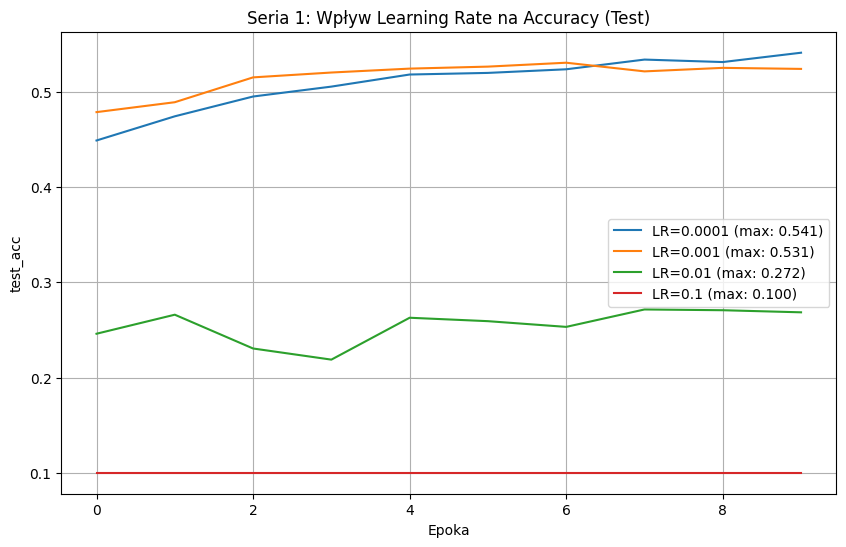

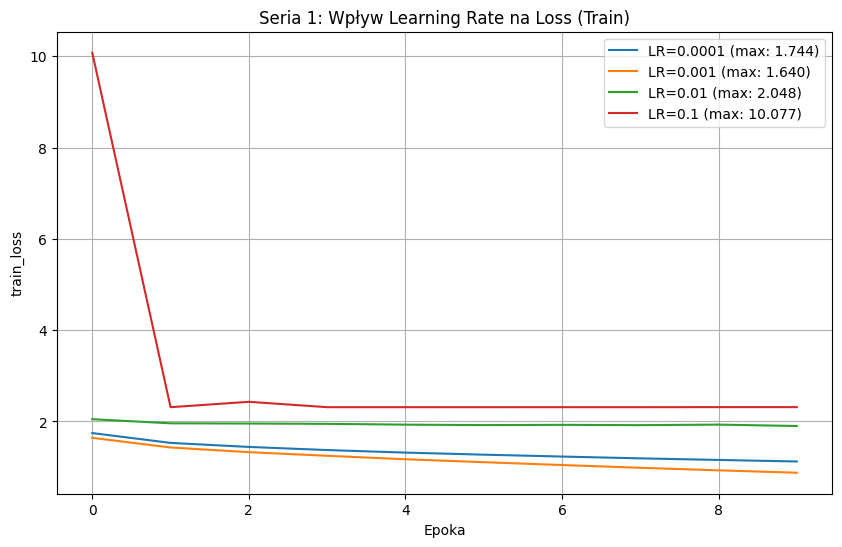

In [4]:
# --- SERIA 1: Learning Rate ---
learning_rates = [0.0001, 0.001, 0.01, 0.1]
results_lr = {}

# Stałe parametry dla tej serii
fixed_batch = 64
fixed_hidden = [256, 128]
trainloader = torch.utils.data.DataLoader(trainset, batch_size=fixed_batch, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=fixed_batch, shuffle=False)

print("Rozpoczęcie Serii 1: Learning Rate...")
for lr in learning_rates:
    print(f"Trenowanie dla lr={lr}")
    model = CIFAR10_MLP(hidden_layers=fixed_hidden).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    hist = train_model(model, trainloader, testloader, criterion, optimizer, epochs=10)
    results_lr[f'LR={lr}'] = hist

plot_experiments(results_lr, metric='test_acc', title='Seria 1: Wpływ Learning Rate na Accuracy (Test)')
plot_experiments(results_lr, metric='train_loss', title='Seria 1: Wpływ Learning Rate na Loss (Train)')

**Wnioski - Seria 1 (Learning Rate):** Jak wynika z wykresów, zbyt wysoki współczynnik uczenia (np. 0.1) uniemożliwia sieci naukę (błąd nie spada, dokładność oscyluje na poziomie zgadywania ok. 10%). Najlepsze wyniki dla optymalizatora Adam zazwyczaj osiągane są dla wartości $0.001$ lub $0.0001$. Do kolejnych eksperymentów wybieramy **LR = 0.001**.


Rozpoczęcie Serii 2: Batch Size...
Trenowanie dla batch_size=16
Trenowanie dla batch_size=32
Trenowanie dla batch_size=64
Trenowanie dla batch_size=128


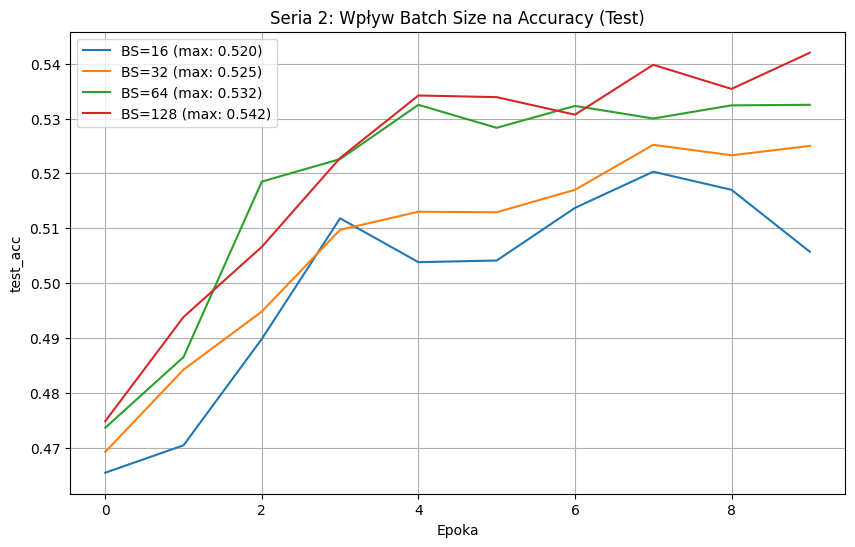

In [5]:
# --- SERIA 2: Batch Size ---
batch_sizes = [16, 32, 64, 128]
results_bs = {}

fixed_lr = 0.001

print("\nRozpoczęcie Serii 2: Batch Size...")
for bs in batch_sizes:
    print(f"Trenowanie dla batch_size={bs}")
    trainloader_bs = torch.utils.data.DataLoader(trainset, batch_size=bs, shuffle=True)
    testloader_bs = torch.utils.data.DataLoader(testset, batch_size=bs, shuffle=False)
    
    model = CIFAR10_MLP(hidden_layers=fixed_hidden).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=fixed_lr)
    
    hist = train_model(model, trainloader_bs, testloader_bs, criterion, optimizer, epochs=10)
    results_bs[f'BS={bs}'] = hist

plot_experiments(results_bs, metric='test_acc', title='Seria 2: Wpływ Batch Size na Accuracy (Test)')

**Wnioski - Seria 2 (Batch Size):** Mniejszy batch size (np. 16, 32) sprawia, że aktualizacje wag są częstsze, ale bardziej "zaszumione". Większy batch (128) stabilizuje gradient, ale może wymagać większej liczby epok do osiągnięcia wysokiej skuteczności. Jako optymalny kompromis między szybkością uczenia a wydajnością, do dalszych kroków wybieramy **Batch Size = 64**.


Rozpoczęcie Serii 3: Architektura (liczba neuronów)...
Trenowanie dla architektury=[64, 32]
Trenowanie dla architektury=[128, 64]
Trenowanie dla architektury=[256, 128]
Trenowanie dla architektury=[512, 256]


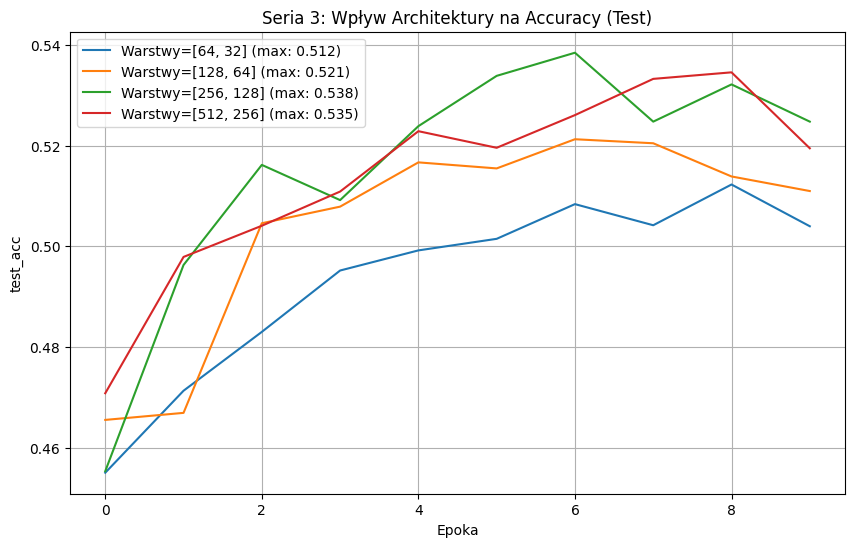

In [6]:
# --- SERIA 3: Liczba neuronów w warstwach ukrytych ---
architectures = [
    [64, 32],
    [128, 64],
    [256, 128],
    [512, 256]
]
results_arch = {}

print("\nRozpoczęcie Serii 3: Architektura (liczba neuronów)...")
for arch in architectures:
    print(f"Trenowanie dla architektury={arch}")
    model = CIFAR10_MLP(hidden_layers=arch).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=fixed_lr)
    
    hist = train_model(model, trainloader, testloader, criterion, optimizer, epochs=10)
    results_arch[f'Warstwy={arch}'] = hist

plot_experiments(results_arch, metric='test_acc', title='Seria 3: Wpływ Architektury na Accuracy (Test)')

**Wnioski - Seria 3 (Architektura):**
Zbyt mała liczba neuronów (64, 32) ogranicza "pojemność" sieci, przez co nie jest ona w stanie wyłapać skomplikowanych cech obrazów. Zwiększenie liczby neuronów do (512, 256) podnosi dokładność, ale znacząco zwiększa liczbę parametrów modelu (co może prowadzić do overfittingu). Do finałowego eksperymentu wybieramy model o szerokości **[512, 256]**.


Rozpoczęcie Serii 4: Dropout...
Trenowanie dla dropout=0.0
Trenowanie dla dropout=0.3
Trenowanie dla dropout=0.5


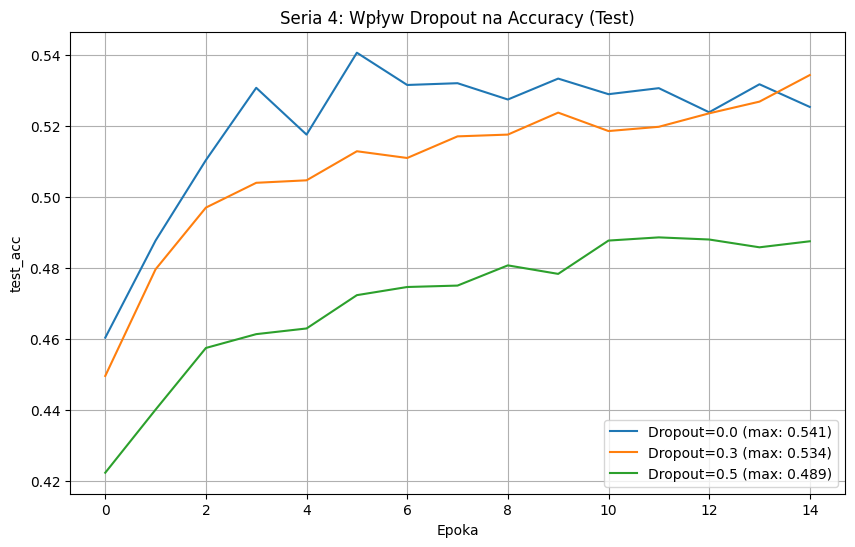

In [7]:
# --- SERIA 4: Wpływ mechanizmu Dropout ---
dropout_rates = [0.0, 0.3, 0.5]
results_drop = {}
best_arch = [512, 256]

print("\nRozpoczęcie Serii 4: Dropout...")
for drop in dropout_rates:
    print(f"Trenowanie dla dropout={drop}")
    model = CIFAR10_MLP(hidden_layers=best_arch, dropout_rate=drop).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=fixed_lr)
    
    # Uczymy trochę dłużej (15 epok), ponieważ dropout spowalnia uczenie
    hist = train_model(model, trainloader, testloader, criterion, optimizer, epochs=15) 
    results_drop[f'Dropout={drop}'] = hist

plot_experiments(results_drop, metric='test_acc', title='Seria 4: Wpływ Dropout na Accuracy (Test)')

**Wnioski - Seria 4 (Dropout):**
Brak dropoutu (0.0) sprawia, że sieć szybko uczy się zbioru treningowego (wysoki train_acc), ale słabiej generalizuje na zbiór testowy (rosnąca luka między train_loss a test_loss). Zastosowanie lekkiego dropoutu (np. 0.3) działa jak regularyzacja, poprawiając generalizację. Dropout 0.5 może być zbyt agresywny dla MLP. Wybieramy sieć z parametrami: `LR=0.001`, `BS=64`, `Warstwy=[512, 256]`, `Dropout=0.3`.

---
## 5. Ewaluacja Najlepszego Modelu
Ostatnim krokiem jest wytrenowanie ostatecznego modelu na optymalnych hiperparametrach oraz wygenerowanie pełnych metryk (Accuracy, Macierz Pomyłek, Classification Report) i wizualizacja błędów.


Trenowanie Ostatecznego Modelu...
Końcowe Accuracy na zbiorze testowym: 52.06%

Classification Report:
              precision    recall  f1-score   support

       plane       0.57      0.61      0.59      1000
         car       0.67      0.63      0.65      1000
        bird       0.43      0.37      0.40      1000
         cat       0.34      0.47      0.40      1000
        deer       0.37      0.47      0.41      1000
         dog       0.47      0.25      0.33      1000
        frog       0.56      0.58      0.57      1000
       horse       0.66      0.56      0.61      1000
        ship       0.58      0.70      0.63      1000
       truck       0.66      0.55      0.60      1000

    accuracy                           0.52     10000
   macro avg       0.53      0.52      0.52     10000
weighted avg       0.53      0.52      0.52     10000



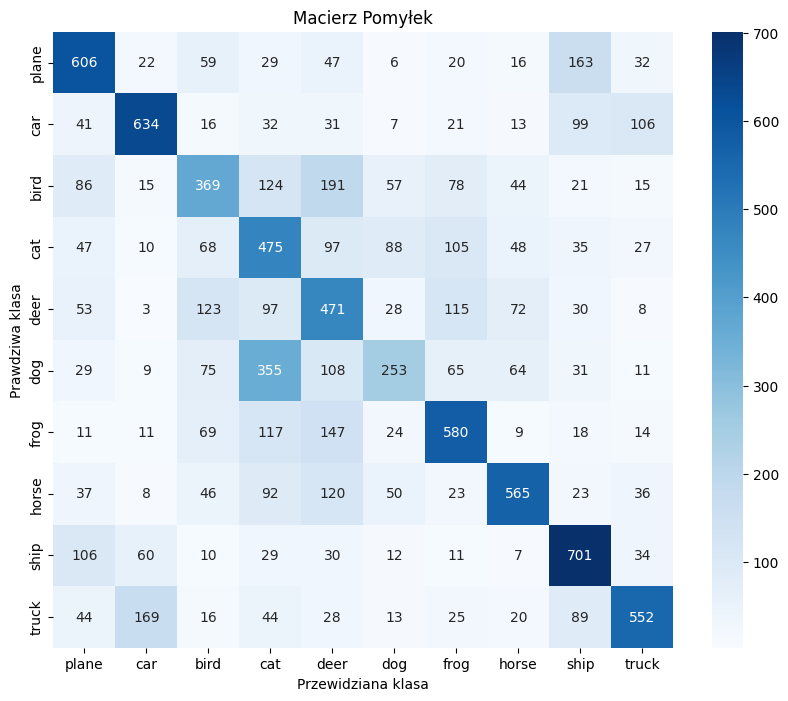


Przykłady błędnie sklasyfikowanych obrazów:


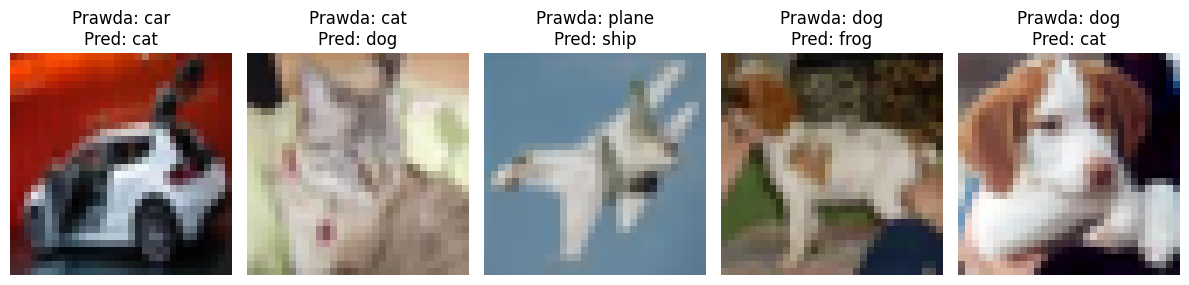

In [8]:
print("\nTrenowanie Ostatecznego Modelu...")
best_model = CIFAR10_MLP(hidden_layers=[512, 256], dropout_rate=0.3).to(device)
optimizer = optim.Adam(best_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Trening finalnego modelu (15 epok)
final_history = train_model(best_model, trainloader, testloader, criterion, optimizer, epochs=15)

# --- Generowanie Metryk ---
best_model.eval()
all_preds = []
all_labels = []
misclassified_imgs = []
misclassified_preds = []
misclassified_trues = []

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = best_model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        # Zbieranie błędnie sklasyfikowanych próbek
        for i in range(len(preds)):
            if preds[i] != labels[i] and len(misclassified_imgs) < 5:
                misclassified_imgs.append(inputs[i].cpu())
                misclassified_preds.append(preds[i].item())
                misclassified_trues.append(labels[i].item())

# Accuracy
print(f"Końcowe Accuracy na zbiorze testowym: {accuracy_score(all_labels, all_preds)*100:.2f}%\n")

# Classification Report
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))

# Macierz pomyłek
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Macierz Pomyłek')
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Przewidziana klasa')
plt.show()

# --- Wizualizacja Błędów ---
print("\nPrzykłady błędnie sklasyfikowanych obrazów:")
fig = plt.figure(figsize=(12, 4))
for i in range(5):
    ax = fig.add_subplot(1, 5, i+1)
    imshow(misclassified_imgs[i])
    ax.set_title(f"Prawda: {classes[misclassified_trues[i]]}\nPred: {classes[misclassified_preds[i]]}")
plt.tight_layout()
plt.show()

## Wnioski Końcowe
1. Sieci w pełni połączone (MLP) mają istotne ograniczenia w przetwarzaniu obrazów. Spłaszczanie (Flatten) powoduje całkowitą utratę dwuwymiarowej (przestrzennej) struktury obrazu. Mimo to model potrafi osiągnąć skuteczność rzędu ~50-55% (co jest znacznie lepsze niż losowe zgadywanie równe 10%).
2. Z macierzy pomyłek widać, że model najczęściej myli ze sobą podobne wizualnie obiekty, na przykład: kota z psem, czy ciężarówkę z samochodem.
3. Aby osiągnąć wyniki z rzędu >80-90% na zbiorze CIFAR-10, konieczne jest użycie Sieci Konwolucyjnych (CNN), które operują bezpośrednio na strukturze 2D używając filtrów splotowych.